# task 1 -> inductive biases and feature representations

## imports

In [1]:
# !pip install -q open_clip_torch

In [ ]:
from pathlib import Path
import itertools
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision.datasets import STL10
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torchvision.models import resnet50, ResNet50_Weights, vit_b_16, ViT_B_16_Weights

import open_clip
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm


#seed 6304 fixed by the assignment
SEED = 6304
torch.manual_seed(SEED) 
np.random.seed(SEED) 
random.seed(SEED) 
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'using device {device}')

DATA_DIR = Path('./data') 
OUTPUT_DIR = Path('./outputs/task1_inductive_bias')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


using device cuda


## global env variables ->

In [ ]:
#same order as stl10's integer labels, clip prompts are built off these too
CLASS_NAMES = ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
NUM_CLASSES = 10

#all interventions go on one shared 224 uint8 canvas, per model normalisation only happens at encode time
IMAGE_SIZE = 224
BATCH_SIZE = 128
NUM_WORKERS = 4

HEAD_LEARNING_RATE = 1e-3 #head hyperparams fixed by the assignment
HEAD_WEIGHT_DECAY = 1e-4
HEAD_MAX_EPOCHS = 50
HEAD_PATIENCE = 5

EVAL_SUBSET_SIZE = 500 #50 per class
ZERO_SHOT_TEMPLATE = 'a photo of a {}.'

HUE_ROTATION = 0.5 #half a turn ie the biggest hue change possible

TRANSLATION_SHIFTS = [0, 8, 16, 32]
#signs are the crop offset not the motion, so up is +1 on rows (checked against a marker pixel)
TRANSLATION_DIRECTIONS = {'up': (1, 0), 'down': (-1, 0), 'left': (0, 1), 'right': (0, -1)}
REPRESENTATION_SHIFT = 16 #middle nonzero shift for the representation table

PATCH_GRID = 4

STYLE_ALPHA = 0.8 #below 1 so the silhouette survives and the edge check still works
CONFLICTS_PER_DIRECTION = 24
MIN_ACCEPTED_CONFLICTS = 200
EDGE_CORRELATION_FLOOR = 0.35

CLASS_PAIRS = [ #man made vs animal so shape and texture actually disagree
    ('airplane', 'cat'), ('car', 'deer'), ('ship', 'dog'), ('truck', 'bird'), ('airplane', 'horse'), ('car', 'monkey'),
]

#adain weights from the naoto0804/pytorch-AdaIN release (huang & belongie 2017), hf mirror of the drive links
ADAIN_VGG_URL = 'https://huggingface.co/BhupatiNadar/adain-style-transfer-models/resolve/main/vgg_normalized.pth'
ADAIN_DECODER_URL = 'https://huggingface.co/BhupatiNadar/adain-style-transfer-models/resolve/main/decoder_final.pth'

TSNE_SETTINGS = {'perplexity': 30, 'init': 'pca', 'learning_rate': 'auto', 'random_state': SEED}
PCA_COMPONENTS = 50 #tsne on raw 2048 dims is painfully slow

## stl10 loading and the shared 224 canvas

In [4]:
#no transform on purpose, raw pil -> canvas below so everything starts from the same pixels
train_split = STL10(root=DATA_DIR, split='train', download=True)
test_split = STL10(root=DATA_DIR, split='test', download=True)

train_labels_all = np.asarray(train_split.labels)
test_labels_all = np.asarray(test_split.labels)

train_indices, val_indices = train_test_split( #stratified 80/20 on indices
    np.arange(len(train_labels_all)), test_size=0.2,
    stratify=train_labels_all, random_state=SEED,
)

subset_generator = np.random.default_rng(SEED) #own rng so other cells cant shift which images get picked
images_per_class = EVAL_SUBSET_SIZE // NUM_CLASSES
eval_indices = []

for class_index, class_name in enumerate(CLASS_NAMES):
    class_indices = np.flatnonzero(test_labels_all == class_index)
    take = min(images_per_class, len(class_indices))
    if take < images_per_class:
        print(f'{class_name} only has {len(class_indices)} test images, taking all of them')
    eval_indices.extend(subset_generator.choice(class_indices, size=take, replace=False).tolist())

eval_indices = np.sort(np.asarray(eval_indices))

print(f'train {len(train_indices)}  val {len(val_indices)}  eval subset {len(eval_indices)}')


  0%|          | 0.00/2.64G [00:00<?, ?B/s]


  0%|          | 32.8k/2.64G [00:00<8:47:14, 83.5kB/s]


  0%|          | 65.5k/2.64G [00:00<8:51:55, 82.7kB/s]


  0%|          | 98.3k/2.64G [00:00<6:50:22, 107kB/s] 


  0%|          | 131k/2.64G [00:01<7:37:53, 96.1kB/s]

...


100%|█████████▉| 2.64G/2.64G [05:09<00:00, 9.09MB/s]


100%|█████████▉| 2.64G/2.64G [05:10<00:00, 9.09MB/s]


100%|█████████▉| 2.64G/2.64G [05:10<00:00, 9.09MB/s]


100%|██████████| 2.64G/2.64G [05:10<00:00, 8.51MB/s]

train 4000  val 1000  eval subset 500


In [5]:
def to_common_canvas(pil_image):
    resized = TF.resize(pil_image, [IMAGE_SIZE, IMAGE_SIZE], interpolation=TF.InterpolationMode.BICUBIC) #96->224, bicubic keeps edges sharper for the edge check
    return TF.pil_to_tensor(resized) #stays uint8 3x224x224, ToTensor would divide by 255


class CommonCanvasDataset(Dataset):
    #streamed since holding 5000 canvases would be ~750mb
    def __init__(self, dataset, indices):
        self.dataset = dataset
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, position):
        image, label = self.dataset[int(self.indices[position])]
        return to_common_canvas(image), label


train_loader = DataLoader(
    CommonCanvasDataset(train_split, train_indices), batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    CommonCanvasDataset(train_split, val_indices), batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)

eval_images = torch.stack([to_common_canvas(test_split[int(index)][0]) for index in tqdm(eval_indices, desc='building eval canvas')]) #500x3x224x224 uint8, every intervention starts from this
eval_labels = torch.tensor(test_labels_all[eval_indices])

pd.DataFrame({
    'test_index': eval_indices,
    'label': eval_labels.numpy(),
    'class_name': [CLASS_NAMES[label] for label in eval_labels.numpy()],
}).to_csv(OUTPUT_DIR / 'eval_subset_indices.csv', index=False)

print(f'eval canvas {tuple(eval_images.shape)} {eval_images.dtype}')


building eval canvas:   0%|          | 0/500 [00:00<?, ?it/s]


building eval canvas:  27%|██▋       | 133/500 [00:00<00:00, 1322.45it/s]


building eval canvas:  53%|█████▎    | 266/500 [00:00<00:00, 1318.89it/s]


building eval canvas:  80%|████████  | 402/500 [00:00<00:00, 1333.33it/s]


building eval canvas: 100%|██████████| 500/500 [00:00<00:00, 1331.81it/s]

eval canvas (500, 3, 224, 224) torch.uint8


## frozen backbones

In [6]:
class ClipImageEncoder(nn.Module):
    def __init__(self, clip_model):
        super().__init__()
        self.clip_model = clip_model

    def forward(self, images):
        return self.clip_model.encode_image(images).float()


resnet_backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
resnet_backbone.fc = nn.Identity() #leaves the 2048 dim pooled feature

vit_backbone = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
vit_backbone.heads = nn.Identity() #forward already picks the cls token so this gives the 768 dim cls

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
clip_tokenizer = open_clip.get_tokenizer('ViT-B-32')

#clip normalisation read off its own preprocess instead of hardcoding
clip_normalize = [step for step in clip_preprocess.transforms if isinstance(step, transforms.Normalize)][0]
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225])

backbones = {
    'resnet50': {'model': resnet_backbone, 'mean': IMAGENET_MEAN, 'std': IMAGENET_STD, 'normalize_feature': False},
    'vit_b_16': {'model': vit_backbone, 'mean': IMAGENET_MEAN, 'std': IMAGENET_STD, 'normalize_feature': False},
    'clip_vit_b_32': {'model': ClipImageEncoder(clip_model), 'mean': torch.tensor(clip_normalize.mean),
                      'std': torch.tensor(clip_normalize.std), 'normalize_feature': True},
}

for name, entry in backbones.items():
    entry['model'] = entry['model'].to(device).eval().requires_grad_(False) #frozen
    entry['mean'] = entry['mean'].view(1, 3, 1, 1).to(device) #1x3x1x1 for broadcasting
    entry['std'] = entry['std'].view(1, 3, 1, 1).to(device)

clip_model = clip_model.to(device).eval()
print('clip normalisation', clip_normalize.mean, clip_normalize.std)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth



  0%|          | 0.00/97.8M [00:00<?, ?B/s]


 14%|█▍        | 14.0M/97.8M [00:00<00:00, 146MB/s]


 29%|██▊       | 28.0M/97.8M [00:00<00:00, 136MB/s]


 42%|████▏     | 41.0M/97.8M [00:00<00:00, 129MB/s]

...


 93%|█████████▎| 308M/330M [00:01<00:00, 194MB/s]


 99%|█████████▉| 326M/330M [00:01<00:00, 194MB/s]


100%|██████████| 330M/330M [00:01<00:00, 188MB/s]

/usr/local/lib/python3.11/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


clip normalisation (0.48145466, 0.4578275, 0.40821073) (0.26862954, 0.26130258, 0.27577711)


In [7]:
@torch.no_grad()
def encode_batch(entry, images_uint8):
    images = images_uint8.to(device, non_blocking=True).float().div(255)
    images = (images - entry['mean']) / entry['std'] #per model normalisation, only after the intervention
    features = entry['model'](images)
    if entry['normalize_feature']:
        features = F.normalize(features, dim=1) #clip rep is the normalised embedding
    return features.float().cpu() #cpu so many conditions fit at once


@torch.no_grad()
def encode_images(entry, images_uint8, description=None):
    outputs = []
    starts = range(0, len(images_uint8), BATCH_SIZE)
    if description is not None:
        starts = tqdm(starts, desc=description, leave=False)
    for start in starts:
        outputs.append(encode_batch(entry, images_uint8[start:start + BATCH_SIZE]))
    return torch.cat(outputs)


@torch.no_grad()
def encode_all_backbones(images_uint8, description):
    return {name: encode_images(entry, images_uint8, f'{description} | {name}') for name, entry in backbones.items()}


@torch.no_grad()
def extract_loader_features(loader, description):
    #all three backbones in one loop so each image is only decoded once
    collected = {name: [] for name in backbones}
    all_labels = []

    for images_uint8, labels in tqdm(loader, desc=description):
        for name, entry in backbones.items():
            collected[name].append(encode_batch(entry, images_uint8))
        all_labels.append(labels)

    return {name: torch.cat(values) for name, values in collected.items()}, torch.cat(all_labels)


train_features, train_targets = extract_loader_features(train_loader, 'train features')
val_features, val_targets = extract_loader_features(val_loader, 'val features')

for name in backbones:
    print(f'{name:14s} train {tuple(train_features[name].shape)}  val {tuple(val_features[name].shape)}')


train features:   0%|          | 0/32 [00:00<?, ?it/s]


train features:   3%|▎         | 1/32 [00:01<01:00,  1.95s/it]


train features:   6%|▋         | 2/32 [00:02<00:27,  1.11it/s]


train features:   9%|▉         | 3/32 [00:02<00:16,  1.76it/s]


train features:  12%|█▎        | 4/32 [00:02<00:11,  2.44it/s]

...


val features:  75%|███████▌  | 6/8 [00:01<00:00,  4.66it/s]


val features:  88%|████████▊ | 7/8 [00:02<00:00,  5.05it/s]


val features: 100%|██████████| 8/8 [00:02<00:00,  5.60it/s]


val features: 100%|██████████| 8/8 [00:02<00:00,  3.65it/s]

resnet50       train (4000, 2048)  val (1000, 2048)
vit_b_16       train (4000, 768)  val (1000, 768)
clip_vit_b_32  train (4000, 512)  val (1000, 512)


## linear classifier heads

In [8]:
criterion = nn.CrossEntropyLoss()

def train_linear_head(features, targets, validation_features, validation_targets, head_name):
    torch.manual_seed(SEED) #reseed so every head gets the same init draw
    head = nn.Linear(features.shape[1], NUM_CLASSES).to(device)
    optimizer = torch.optim.AdamW(head.parameters(), lr=HEAD_LEARNING_RATE, weight_decay=HEAD_WEIGHT_DECAY)

    feature_loader = DataLoader(TensorDataset(features, targets), batch_size=BATCH_SIZE, shuffle=True) #cached features, backbone is frozen
    validation_features = validation_features.to(device)

    history = []
    best_validation_accuracy = 0.0
    best_weights = None
    epochs_without_improvement = 0

    for epoch in range(HEAD_MAX_EPOCHS):
        head.train()
        running_loss = 0.0
        total_predictions = 0

        for batch_features, batch_labels in feature_loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)
            optimizer.zero_grad()

            loss = criterion(head(batch_features), batch_labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * batch_labels.size(0) #sum over images, last batch is smaller
            total_predictions += batch_labels.size(0)

        head.eval()
        with torch.no_grad():
            validation_predictions = head(validation_features).argmax(dim=1).cpu()
        validation_accuracy = 100 * (validation_predictions == validation_targets).float().mean().item()

        history.append({
            'head': head_name,
            'epoch': epoch + 1,
            'train_loss': running_loss / total_predictions,
            'validation_accuracy': validation_accuracy,
        })

        if validation_accuracy > best_validation_accuracy:
            best_validation_accuracy = validation_accuracy
            best_weights = {name: tensor.detach().cpu().clone() for name, tensor in head.state_dict().items()} #clone so later steps dont overwrite it
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= HEAD_PATIENCE:
                print(f'{head_name} stopped early at epoch {epoch + 1}')
                break

    head.load_state_dict(best_weights) #best not last
    print(f'{head_name} best validation accuracy {best_validation_accuracy:.2f}%')
    return head.eval(), pd.DataFrame(history), best_validation_accuracy


heads = {}
head_histories = []
head_summary = []

for name in backbones:
    head, history, best_accuracy = train_linear_head(
        train_features[name], train_targets, val_features[name], val_targets, name
    )
    heads[name] = head
    head_histories.append(history)
    head_summary.append({'backbone': name, 'feature_dimension': train_features[name].shape[1],
                         'epochs_trained': len(history), 'best_validation_accuracy': best_accuracy})

pd.concat(head_histories).to_csv(OUTPUT_DIR / 'head_training_history.csv', index=False)
display(pd.DataFrame(head_summary))

resnet50 stopped early at epoch 11
resnet50 best validation accuracy 97.20%


vit_b_16 stopped early at epoch 17
vit_b_16 best validation accuracy 98.00%


clip_vit_b_32 stopped early at epoch 8
clip_vit_b_32 best validation accuracy 98.50%


,backbone,feature_dimension,epochs_trained,best_validation_accuracy
0,resnet50,2048,11,97.200000
1,vit_b_16,768,17,98.000002
2,clip_vit_b_32,512,8,98.500001


## clip zero shot classifier and the evaluation registry

In [9]:
@torch.no_grad()
def build_zero_shot_weights():
    prompts = [ZERO_SHOT_TEMPLATE.format(class_name) for class_name in CLASS_NAMES]
    tokens = clip_tokenizer(prompts).to(device)
    embeddings = clip_model.encode_text(tokens).float() #(10, 512)
    return F.normalize(embeddings, dim=1) #so dot product = cosine sim


zero_shot_weights = build_zero_shot_weights()

clip_logit_scale = clip_model.logit_scale.exp().item() #stored as a log

evaluation_models = {
    'resnet50 head': {'backbone': 'resnet50', 'logits': heads['resnet50']},
    'vit_b_16 head': {'backbone': 'vit_b_16', 'logits': heads['vit_b_16']},
    'clip head': {'backbone': 'clip_vit_b_32', 'logits': heads['clip_vit_b_32']},
    'clip zero shot': {'backbone': 'clip_vit_b_32', 'logits': lambda features: clip_logit_scale * features @ zero_shot_weights.T},
}

print(f'clip logit scale {clip_logit_scale:.2f}')

clip logit scale 100.00


In [10]:
@torch.no_grad()
def compute_logits(model_name, condition_features):
    specification = evaluation_models[model_name]
    features = condition_features[specification['backbone']].to(device)
    return specification['logits'](features).cpu() #(n, 10)


def evaluate_condition(condition_name, images_uint8, labels, clean_predictions=None):
    condition_features = encode_all_backbones(images_uint8, condition_name) #shared so clip head and zero shot share one pass
    rows = []
    predictions = {}

    for model_name in evaluation_models:
        logits = compute_logits(model_name, condition_features)
        probabilities = logits.softmax(dim=1) #clip head has no logit scale so its confidence isnt comparable across models
        predicted = logits.argmax(dim=1)
        predictions[model_name] = predicted

        row = {
            'condition': condition_name,
            'model': model_name,
            'accuracy': 100 * (predicted == labels).float().mean().item(),
            'macro_f1': 100 * f1_score(labels.numpy(), predicted.numpy(), average='macro'),
            'mean_max_confidence': probabilities.max(dim=1).values.mean().item(),
        }
        if clean_predictions is not None:
            #consistency != accuracy, wrong the same way before and after still counts
            row['prediction_consistency'] = 100 * (predicted == clean_predictions[model_name]).float().mean().item()
        rows.append(row)

    return pd.DataFrame(rows), predictions, condition_features

## experiment 1 : clean baseline

In [11]:
#hypothesis -> 3 heads land close, zero shot clip trails its own head (never sees stl10) | metric -> acc, macro f1, mean max conf
clean_results, clean_predictions, clean_features = evaluate_condition('clean', eval_images, eval_labels)
clean_results.to_csv(OUTPUT_DIR / 'clean_baseline.csv', index=False)
display(clean_results)


clean | resnet50:   0%|          | 0/4 [00:00<?, ?it/s]


clean | resnet50:  75%|███████▌  | 3/4 [00:00<00:00, 27.89it/s]


clean | vit_b_16:   0%|          | 0/4 [00:00<?, ?it/s]


clean | vit_b_16:  25%|██▌       | 1/4 [00:00<00:00,  9.57it/s]


clean | vit_b_16:  50%|█████     | 2/4 [00:00<00:00,  9.55it/s]


clean | vit_b_16:  75%|███████▌  | 3/4 [00:00<00:00,  9.54it/s]


clean | clip_vit_b_32:   0%|          | 0/4 [00:00<?, ?it/s]


clean | clip_vit_b_32: 100%|██████████| 4/4 [00:00<00:00, 35.55it/s]

,condition,model,accuracy,macro_f1,mean_max_confidence
0,clean,resnet50 head,97.600001,97.605553,0.894992
1,clean,vit_b_16 head,97.399998,97.389475,0.961627
2,clean,clip head,97.600001,97.594204,0.161847
3,clean,clip zero shot,96.799999,96.752408,0.942696


## experiment 2 : colour bias

In [12]:
def grayscale_images(images_uint8):
    return TF.rgb_to_grayscale(images_uint8, num_output_channels=3) #3 identical channels since backbones want rgb


def hue_rotated_images(images_uint8):
    return TF.adjust_hue(images_uint8, HUE_ROTATION) #keeps saturation so its the wrong colour rather than no colour


#hypothesis -> colour reliant models drop on grayscale and more on hue (wrong > absent) | metric -> acc change + consistency vs clean
colour_conditions = {
    'grayscale': grayscale_images(eval_images),
    'hue rotated': hue_rotated_images(eval_images),
}

colour_results = []
colour_predictions = {}
colour_features = {}

for condition_name, condition_images in colour_conditions.items():
    results, predictions, features = evaluate_condition(condition_name, condition_images, eval_labels, clean_predictions)
    colour_results.append(results)
    colour_predictions[condition_name] = predictions
    colour_features[condition_name] = features

colour_results = pd.concat(colour_results, ignore_index=True)
colour_results.to_csv(OUTPUT_DIR / 'colour_bias.csv', index=False)
display(colour_results)


grayscale | resnet50:   0%|          | 0/4 [00:00<?, ?it/s]


grayscale | resnet50:  75%|███████▌  | 3/4 [00:00<00:00, 27.52it/s]


grayscale | vit_b_16:   0%|          | 0/4 [00:00<?, ?it/s]


grayscale | vit_b_16:  25%|██▌       | 1/4 [00:00<00:00,  9.58it/s]


grayscale | vit_b_16:  50%|█████     | 2/4 [00:00<00:00,  9.56it/s]

...


hue rotated | vit_b_16:  50%|█████     | 2/4 [00:00<00:00,  9.57it/s]


hue rotated | vit_b_16:  75%|███████▌  | 3/4 [00:00<00:00,  9.55it/s]


hue rotated | clip_vit_b_32:   0%|          | 0/4 [00:00<?, ?it/s]


hue rotated | clip_vit_b_32: 100%|██████████| 4/4 [00:00<00:00, 35.46it/s]

,condition,model,accuracy,macro_f1,mean_max_confidence,prediction_consistency
0,grayscale,resnet50 head,95.599997,95.586135,0.900452,96.399999
1,grayscale,vit_b_16 head,95.599997,95.585233,0.955041,95.200002
2,grayscale,clip head,95.599997,95.570626,0.155611,95.599997
3,grayscale,clip zero shot,94.199997,94.111822,0.928213,95.200002
4,hue rotated,resnet50 head,93.199998,93.246931,0.897188,94.599998
5,hue rotated,vit_b_16 head,94.199997,94.183716,0.923252,94.599998
6,hue rotated,clip head,94.999999,94.943699,0.152490,95.599997
7,hue rotated,clip zero shot,93.400002,93.314952,0.917291,94.199997


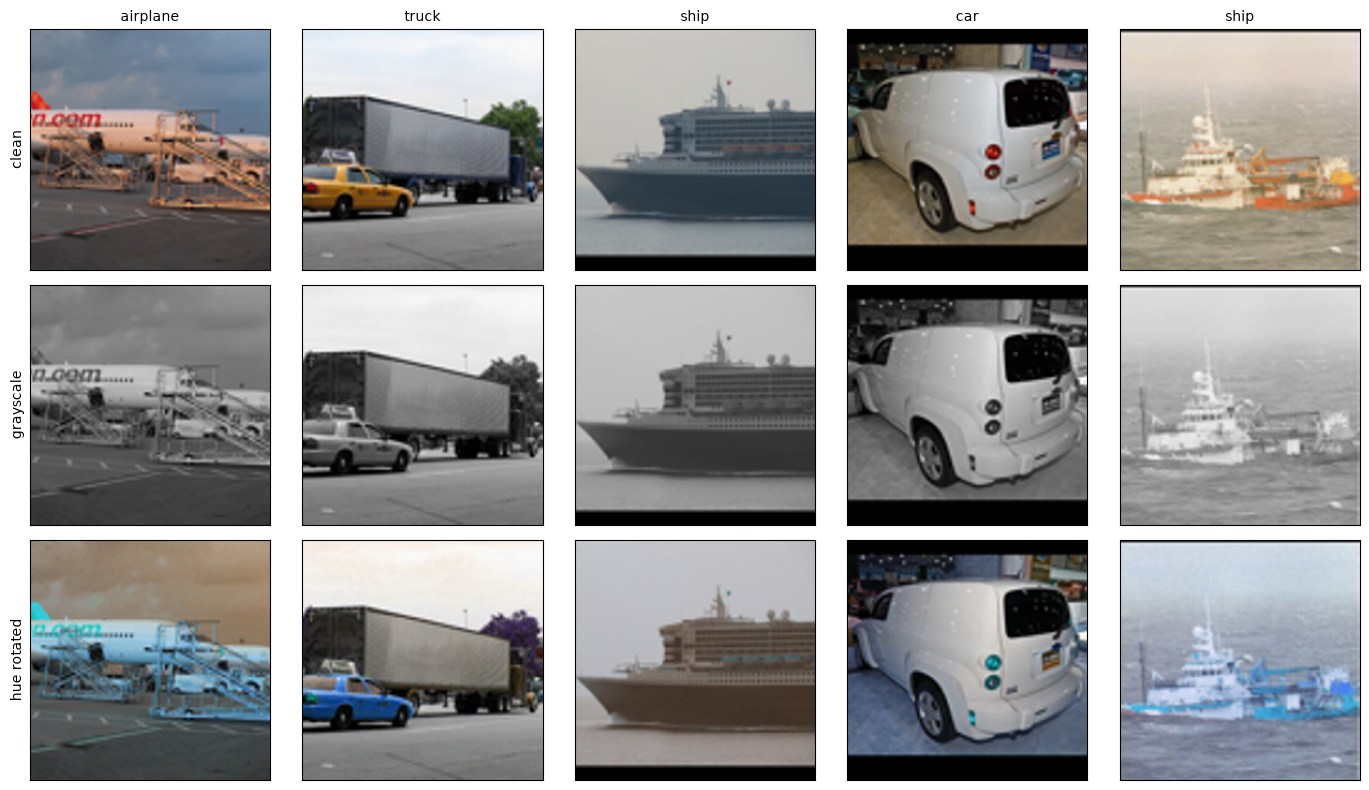

In [13]:
sample_positions = np.linspace(0, len(eval_images) - 1, 5).astype(int)
condition_rows = [('clean', eval_images), ('grayscale', colour_conditions['grayscale']), ('hue rotated', colour_conditions['hue rotated'])]

fig, axes = plt.subplots(len(condition_rows), len(sample_positions), figsize=(14, 8))
for column, position in enumerate(sample_positions):
    for row, (row_name, row_images) in enumerate(condition_rows):
        axes[row, column].imshow(row_images[position].permute(1, 2, 0)) #chw->hwc
        axes[row, column].set_xticks([])
        axes[row, column].set_yticks([])
    axes[0, column].set_title(CLASS_NAMES[eval_labels[position]], fontsize=10)

for row, (row_name, _) in enumerate(condition_rows):
    axes[row, 0].set_ylabel(row_name)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'colour_interventions.png', dpi=180, bbox_inches='tight')
plt.show()

## adain style transfer used to build the cue conflicts

In [14]:
#normalised vgg19 up to relu4_1, must match the checkpoint index for index
adain_encoder_layers = [
    nn.Conv2d(3, 3, 1), #learned 1x1 colour transform, part of the checkpoint
    nn.ReflectionPad2d(1), nn.Conv2d(3, 64, 3), nn.ReLU(),
    nn.ReflectionPad2d(1), nn.Conv2d(64, 64, 3), nn.ReLU(),
    nn.MaxPool2d(2, 2, ceil_mode=True),
    nn.ReflectionPad2d(1), nn.Conv2d(64, 128, 3), nn.ReLU(),
    nn.ReflectionPad2d(1), nn.Conv2d(128, 128, 3), nn.ReLU(),
    nn.MaxPool2d(2, 2, ceil_mode=True),
    nn.ReflectionPad2d(1), nn.Conv2d(128, 256, 3), nn.ReLU(),
    nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(),
    nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(),
    nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(),
    nn.MaxPool2d(2, 2, ceil_mode=True),
    nn.ReflectionPad2d(1), nn.Conv2d(256, 512, 3), nn.ReLU(), #relu4_1 -> n by 512 by 28 by 28
]

adain_decoder_layers = [ #mirrors the encoder, 28->224
    nn.ReflectionPad2d(1), nn.Conv2d(512, 256, 3), nn.ReLU(),
    nn.Upsample(scale_factor=2, mode='nearest'),
    nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(),
    nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(),
    nn.ReflectionPad2d(1), nn.Conv2d(256, 256, 3), nn.ReLU(),
    nn.ReflectionPad2d(1), nn.Conv2d(256, 128, 3), nn.ReLU(),
    nn.Upsample(scale_factor=2, mode='nearest'),
    nn.ReflectionPad2d(1), nn.Conv2d(128, 128, 3), nn.ReLU(),
    nn.ReflectionPad2d(1), nn.Conv2d(128, 64, 3), nn.ReLU(),
    nn.Upsample(scale_factor=2, mode='nearest'),
    nn.ReflectionPad2d(1), nn.Conv2d(64, 64, 3), nn.ReLU(),
    nn.ReflectionPad2d(1), nn.Conv2d(64, 3, 3), #no activation, clamped later
]

DATA_DIR.mkdir(parents=True, exist_ok=True)
adain_vgg_path = DATA_DIR / 'adain_vgg_normalized.pth'
adain_decoder_path = DATA_DIR / 'adain_decoder.pth'
if not adain_vgg_path.exists():
    torch.hub.download_url_to_file(ADAIN_VGG_URL, adain_vgg_path)
if not adain_decoder_path.exists():
    torch.hub.download_url_to_file(ADAIN_DECODER_URL, adain_decoder_path)

style_encoder = nn.Sequential(*adain_encoder_layers)
encoder_state = torch.load(adain_vgg_path, map_location='cpu')
missing, unexpected = style_encoder.load_state_dict(encoder_state, strict=False) #file has the full vgg, we only built up to relu4_1
assert not missing, f'encoder is missing weights {missing}'

style_decoder = nn.Sequential(*adain_decoder_layers)
decoder_state = torch.load(adain_decoder_path, map_location='cpu')
decoder_state = {name.replace('net.', '', 1): tensor for name, tensor in decoder_state.items()} #decoder keys carry a net. prefix, stripped here
style_decoder.load_state_dict(decoder_state)

style_encoder = style_encoder.to(device).eval().requires_grad_(False)
style_decoder = style_decoder.to(device).eval().requires_grad_(False)
print(f'adain encoder loaded, dropped {len(unexpected)} keys past relu4_1')


  0%|          | 0.00/76.4M [00:00<?, ?B/s]


  0%|          | 128k/76.4M [00:00<04:25, 302kB/s]


  8%|▊         | 6.00M/76.4M [00:00<00:04, 15.5MB/s]


 22%|██▏       | 17.1M/76.4M [00:00<00:01, 41.8MB/s]


 37%|███▋      | 28.0M/76.4M [00:00<00:00, 61.3MB/s]

...


  0%|          | 0.00/13.4M [00:00<?, ?B/s]


  1%|          | 128k/13.4M [00:00<00:28, 493kB/s]


 54%|█████▍    | 7.25M/13.4M [00:00<00:00, 26.3MB/s]


100%|██████████| 13.4M/13.4M [00:00<00:00, 33.7MB/s]

adain encoder loaded, dropped 14 keys past relu4_1


In [15]:
def feature_mean_std(features, eps=1e-5):
    mean = features.mean(dim=(2, 3), keepdim=True) #n by c by 1 by 1
    standard_deviation = (features.var(dim=(2, 3), keepdim=True) + eps).sqrt()
    return mean, standard_deviation


def adaptive_instance_normalization(content_features, style_features):
    #strip content stats, paint on style stats, spatial layout untouched so shape survives
    content_mean, content_std = feature_mean_std(content_features)
    style_mean, style_std = feature_mean_std(style_features)
    normalized = (content_features - content_mean) / content_std
    return normalized * style_std + style_mean


@torch.no_grad()
def stylize(content_uint8, style_uint8, alpha=STYLE_ALPHA):
    content = content_uint8.to(device).float().div(255) #no imagenet norm, this vgg was trained on plain 0-1
    style = style_uint8.to(device).float().div(255)

    content_features = style_encoder(content)
    style_features = style_encoder(style)

    mixed = adaptive_instance_normalization(content_features, style_features)
    mixed = alpha * mixed + (1 - alpha) * content_features

    output = style_decoder(mixed).clamp(0, 1)
    return output.mul(255).round().to(torch.uint8).cpu()

## the cue conflict rejection rule

In [16]:
#rejection rule, no model predictions used -> edge corr >= 0.35 (content kept) and palette closer to style (style applied)

def sobel_edge_magnitude(images_uint8):
    gray = TF.rgb_to_grayscale(images_uint8, num_output_channels=1).float().div(255)
    kernel_x = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]]).view(1, 1, 3, 3)
    kernel_y = kernel_x.transpose(2, 3)
    gradient_x = F.conv2d(gray, kernel_x, padding=1)
    gradient_y = F.conv2d(gray, kernel_y, padding=1)
    return (gradient_x.square() + gradient_y.square()).sqrt().flatten(1) #n by 224*224


def edge_correlation(stylized_uint8, content_uint8):
    #pearson not a diff since stylising changes edge strength, we care about edge location
    stylized_edges = sobel_edge_magnitude(stylized_uint8)
    content_edges = sobel_edge_magnitude(content_uint8)
    stylized_edges = stylized_edges - stylized_edges.mean(dim=1, keepdim=True)
    content_edges = content_edges - content_edges.mean(dim=1, keepdim=True)
    return (stylized_edges * content_edges).sum(dim=1) / (stylized_edges.norm(dim=1) * content_edges.norm(dim=1) + 1e-8)


def colour_statistics(images_uint8):
    values = images_uint8.float().div(255)
    return torch.cat([values.mean(dim=(2, 3)), values.std(dim=(2, 3))], dim=1) #per channel mean and std -> n by 6


def style_was_applied(stylized_uint8, content_uint8, style_uint8):
    stylized_statistics = colour_statistics(stylized_uint8)
    distance_to_content = (stylized_statistics - colour_statistics(content_uint8)).abs().sum(dim=1)
    distance_to_style = (stylized_statistics - colour_statistics(style_uint8)).abs().sum(dim=1)
    return distance_to_style < distance_to_content


def accept_conflicts(stylized_uint8, content_uint8, style_uint8):
    correlations = edge_correlation(stylized_uint8, content_uint8)
    passed_edges = correlations >= EDGE_CORRELATION_FLOOR
    passed_palette = style_was_applied(stylized_uint8, content_uint8, style_uint8)
    return passed_edges & passed_palette, correlations

## experiment 3 : shape versus texture

In [17]:
style_pool_generator = np.random.default_rng(SEED) #styles from train so eval images are only ever content
style_pool = {}
for class_index, class_name in enumerate(CLASS_NAMES):
    class_indices = np.flatnonzero(train_labels_all == class_index)
    chosen = style_pool_generator.choice(class_indices, size=CONFLICTS_PER_DIRECTION, replace=False)
    style_pool[class_name] = torch.stack([to_common_canvas(train_split[int(index)][0]) for index in chosen])

eval_positions_by_class = {class_name: np.flatnonzero(eval_labels.numpy() == class_index)
                           for class_index, class_name in enumerate(CLASS_NAMES)}

ordered_combinations = list(itertools.chain.from_iterable((pair, pair[::-1]) for pair in CLASS_PAIRS)) #both directions, 6 pairs -> 12

generated_images = []
generated_records = []

for content_name, style_name in tqdm(ordered_combinations, desc='generating cue conflicts'):
    content_positions = eval_positions_by_class[content_name][:CONFLICTS_PER_DIRECTION]
    content_batch = eval_images[content_positions]
    style_batch = style_pool[style_name][:len(content_positions)]

    stylized = stylize(content_batch, style_batch)
    accepted, correlations = accept_conflicts(stylized, content_batch, style_batch)

    generated_images.append(stylized)
    for offset, content_position in enumerate(content_positions):
        generated_records.append({
            'content_class': content_name,
            'style_class': style_name,
            'content_eval_position': int(content_position),
            'edge_correlation': correlations[offset].item(),
            'accepted': bool(accepted[offset]),
        })

generated_images = torch.cat(generated_images) #288 by 3 by 224 by 224
generated_records = pd.DataFrame(generated_records)

accepted_counts = generated_records[generated_records['accepted']].groupby(['content_class', 'style_class']).size()
print(f"generated {len(generated_records)}  accepted {int(generated_records['accepted'].sum())}  rejected {int((~generated_records['accepted']).sum())}")
print(f'accepted per direction  min {accepted_counts.min()}  max {accepted_counts.max()}')


generating cue conflicts:   0%|          | 0/12 [00:00<?, ?it/s]


generating cue conflicts:   8%|▊         | 1/12 [00:00<00:01,  9.55it/s]


generating cue conflicts:  25%|██▌       | 3/12 [00:00<00:00, 13.35it/s]


generating cue conflicts:  42%|████▏     | 5/12 [00:00<00:00, 14.45it/s]


generating cue conflicts:  58%|█████▊    | 7/12 [00:00<00:00, 14.84it/s]


generating cue conflicts:  75%|███████▌  | 9/12 [00:00<00:00, 15.16it/s]


generating cue conflicts:  92%|█████████▏| 11/12 [00:00<00:00, 15.35it/s]


generating cue conflicts: 100%|██████████| 12/12 [00:00<00:00, 14.75it/s]

generated 288  accepted 251  rejected 37
accepted per direction  min 17  max 23


In [18]:
#trim every direction to the same count, only if that still clears 200
balanced_count = int(accepted_counts.min())
use_balanced = balanced_count * len(ordered_combinations) >= MIN_ACCEPTED_CONFLICTS

keep_positions = []
for (content_name, style_name), group in generated_records[generated_records['accepted']].groupby(['content_class', 'style_class'], sort=False):
    keep_positions.extend(group.index[:balanced_count].tolist() if use_balanced else group.index.tolist())

keep_positions = np.sort(np.asarray(keep_positions))
conflict_records = generated_records.loc[keep_positions].reset_index(drop=True)
conflict_images = generated_images[keep_positions]

conflict_content_labels = torch.tensor([CLASS_NAMES.index(name) for name in conflict_records['content_class']])
conflict_style_labels = torch.tensor([CLASS_NAMES.index(name) for name in conflict_records['style_class']])
conflict_clean_positions = torch.tensor(conflict_records['content_eval_position'].to_numpy())

generated_records.to_csv(OUTPUT_DIR / 'cue_conflict_generation_log.csv', index=False)
conflict_records.to_csv(OUTPUT_DIR / 'cue_conflict_kept.csv', index=False)

assert len(conflict_records) >= MIN_ACCEPTED_CONFLICTS, f'only {len(conflict_records)} valid conflicts, the floor is {MIN_ACCEPTED_CONFLICTS}'
print(f'keeping {len(conflict_records)} conflicts, {"balanced at" if use_balanced else "unbalanced, smallest direction had"} {balanced_count} per direction')

keeping 204 conflicts, balanced at 17 per direction


In [19]:
#shape = matches content class, texture = matches style class, else other
conflict_features = encode_all_backbones(conflict_images, 'cue conflict')
conflict_predictions = {}
shape_bias_rows = []

for model_name in evaluation_models:
    predicted = compute_logits(model_name, conflict_features).argmax(dim=1)
    conflict_predictions[model_name] = predicted

    shape_decisions = int((predicted == conflict_content_labels).sum())
    texture_decisions = int((predicted == conflict_style_labels).sum())
    decided = shape_decisions + texture_decisions

    shape_bias_rows.append({
        'model': model_name,
        'shape_decisions': shape_decisions,
        'texture_decisions': texture_decisions,
        'other_decisions': len(predicted) - decided,
        'shape_bias': 100 * shape_decisions / decided if decided else float('nan'), #decided images only
        'coverage': 100 * decided / len(predicted), #reported beside shape bias since 90% of 12 decided means little
    })

shape_bias_results = pd.DataFrame(shape_bias_rows)
shape_bias_results.to_csv(OUTPUT_DIR / 'shape_bias.csv', index=False)
display(shape_bias_results)


cue conflict | resnet50:   0%|          | 0/2 [00:00<?, ?it/s]


cue conflict | vit_b_16:   0%|          | 0/2 [00:00<?, ?it/s]


cue conflict | vit_b_16:  50%|█████     | 1/2 [00:00<00:00,  9.44it/s]


cue conflict | clip_vit_b_32:   0%|          | 0/2 [00:00<?, ?it/s]

,model,shape_decisions,texture_decisions,other_decisions,shape_bias,coverage
0,resnet50 head,65,31,108,67.708333,47.058824
1,vit_b_16 head,109,22,73,83.206107,64.215686
2,clip head,121,5,78,96.031746,61.764706
3,clip zero shot,119,6,79,95.200000,61.274510


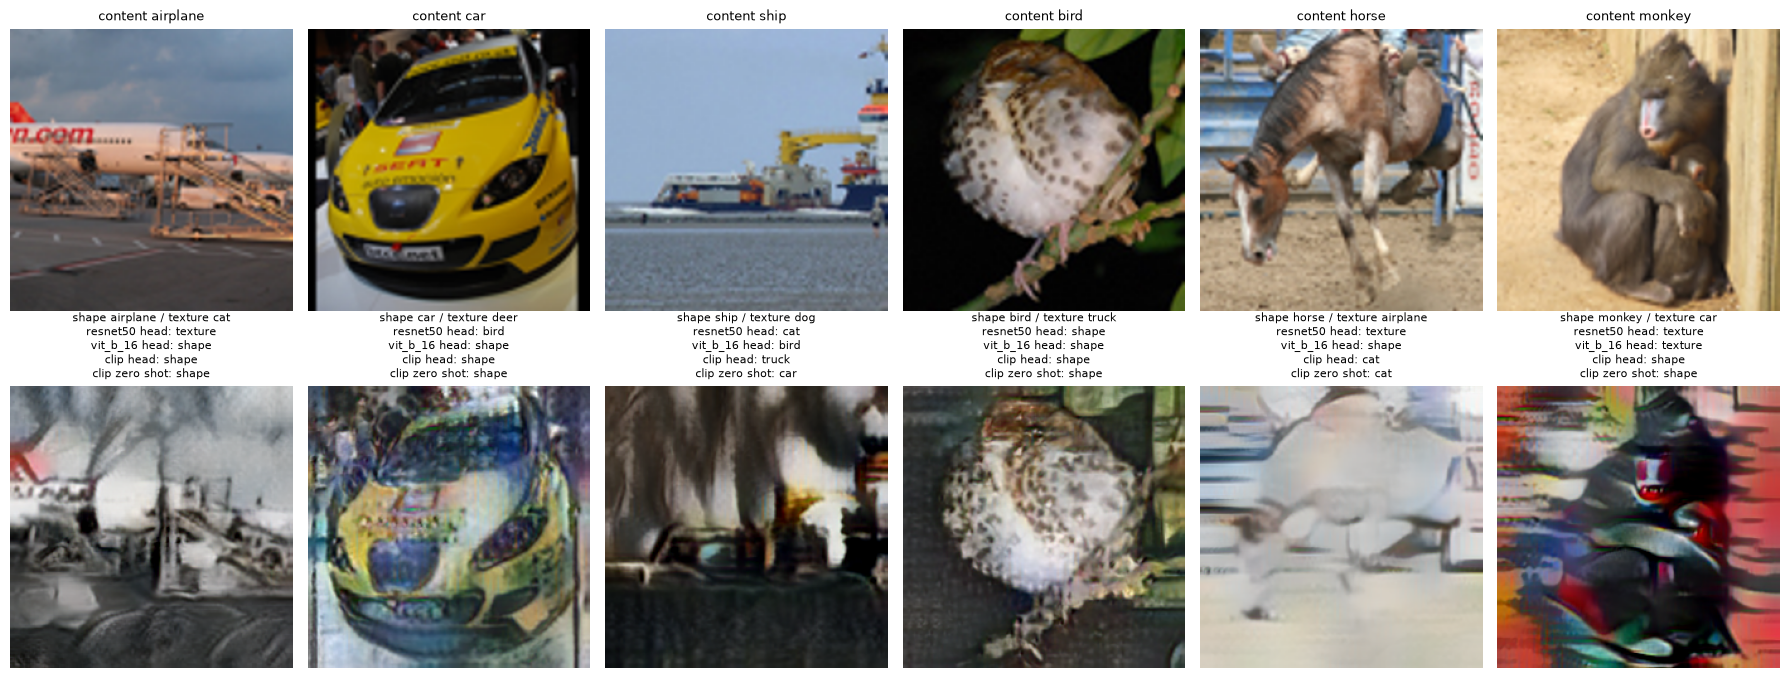

In [20]:
def label_conflict(position, model_name):
    predicted = conflict_predictions[model_name][position].item()
    if predicted == conflict_content_labels[position].item():
        return 'shape'
    if predicted == conflict_style_labels[position].item():
        return 'texture'
    return CLASS_NAMES[predicted]


example_positions = np.linspace(0, len(conflict_images) - 1, 6).astype(int)
fig, axes = plt.subplots(2, 6, figsize=(18, 7))

for column, position in enumerate(example_positions):
    record = conflict_records.iloc[position]
    axes[0, column].imshow(eval_images[int(record['content_eval_position'])].permute(1, 2, 0))
    axes[0, column].set_title(f"content {record['content_class']}", fontsize=9)
    axes[0, column].axis('off')

    axes[1, column].imshow(conflict_images[position].permute(1, 2, 0))
    decisions = '\n'.join(f'{name}: {label_conflict(position, name)}' for name in evaluation_models)
    axes[1, column].set_title(f"shape {record['content_class']} / texture {record['style_class']}\n{decisions}", fontsize=8)
    axes[1, column].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cue_conflict_examples.png', dpi=180, bbox_inches='tight')
plt.show()

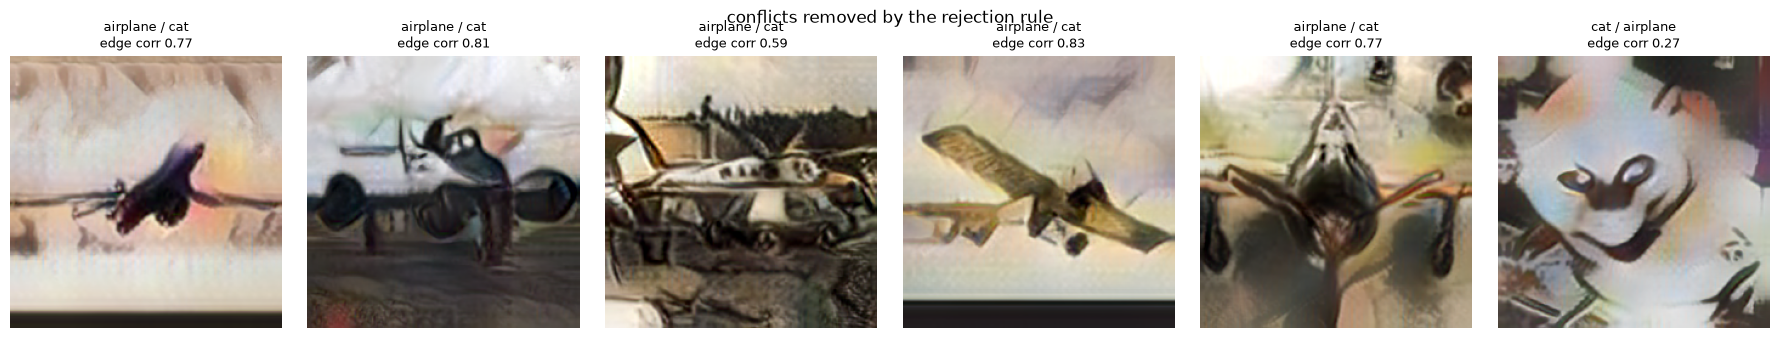

In [21]:
rejected = generated_records[~generated_records['accepted']]

if len(rejected) > 0:
    rejected_positions = rejected.index[:6]
    fig, axes = plt.subplots(1, len(rejected_positions), figsize=(3 * len(rejected_positions), 3.4))
    for axis, position in zip(np.atleast_1d(axes), rejected_positions): #atleast_1d for the single axis case
        record = generated_records.loc[position]
        axis.imshow(generated_images[position].permute(1, 2, 0))
        axis.set_title(f"{record['content_class']} / {record['style_class']}\nedge corr {record['edge_correlation']:.2f}", fontsize=9)
        axis.axis('off')

    plt.suptitle('conflicts removed by the rejection rule')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'cue_conflict_rejected.png', dpi=180, bbox_inches='tight')
    plt.show()
else:
    print('the rejection rule accepted every generated conflict')

## experiment 4 : translation

In [22]:
def translated_images(images_uint8, shift, direction):
    if shift == 0:
        return images_uint8.clone() #so eval_images cant get mutated

    row_sign, column_sign = direction
    top = shift + row_sign * shift #offset shift = original, +1 row takes rows further down so content moves up
    left = shift + column_sign * shift

    chunks = []
    #chunked cuz padding all 500 in float is ~500mb at the biggest shift
    for start in range(0, len(images_uint8), BATCH_SIZE):
        padded = F.pad(images_uint8[start:start + BATCH_SIZE].float(), (shift, shift, shift, shift), mode='reflect') #reflect needs float
        cropped = padded[:, :, top:top + IMAGE_SIZE, left:left + IMAGE_SIZE]
        chunks.append(cropped.round().clamp(0, 255).to(torch.uint8)) #round first, plain cast truncates
    return torch.cat(chunks)


#hypothesis -> conv+pooling gives resnet some tolerance, vit (absolute pos embeddings) moves more | metric -> acc + consistency vs shift
translation_rows = []
representation_translation_features = []

for shift in TRANSLATION_SHIFTS:
    for direction_name, direction in TRANSLATION_DIRECTIONS.items():
        if shift == 0 and direction_name != 'up':
            continue #shift 0 is the same image in every direction

        shifted = translated_images(eval_images, shift, direction)
        condition_name = f'shift {shift} {direction_name}' if shift > 0 else 'shift 0'
        results, _, features = evaluate_condition(condition_name, shifted, eval_labels, clean_predictions)
        results['shift'] = shift
        results['direction'] = direction_name if shift > 0 else 'none'
        translation_rows.append(results)

        if shift == REPRESENTATION_SHIFT:
            representation_translation_features.append(features)

translation_results = pd.concat(translation_rows, ignore_index=True)
translation_curve = translation_results.groupby(['model', 'shift'])[['accuracy', 'prediction_consistency']].mean().reset_index()

translation_results.to_csv(OUTPUT_DIR / 'translation_per_direction.csv', index=False)
translation_curve.to_csv(OUTPUT_DIR / 'translation_curve.csv', index=False)
display(translation_curve)


shift 0 | resnet50:   0%|          | 0/4 [00:00<?, ?it/s]


shift 0 | resnet50:  75%|███████▌  | 3/4 [00:00<00:00, 28.48it/s]


shift 0 | vit_b_16:   0%|          | 0/4 [00:00<?, ?it/s]


shift 0 | vit_b_16:  25%|██▌       | 1/4 [00:00<00:00,  9.55it/s]


shift 0 | vit_b_16:  50%|█████     | 2/4 [00:00<00:00,  9.52it/s]

...


shift 32 right | vit_b_16:  50%|█████     | 2/4 [00:00<00:00,  9.57it/s]


shift 32 right | vit_b_16:  75%|███████▌  | 3/4 [00:00<00:00,  9.55it/s]


shift 32 right | clip_vit_b_32:   0%|          | 0/4 [00:00<?, ?it/s]


shift 32 right | clip_vit_b_32: 100%|██████████| 4/4 [00:00<00:00, 35.56it/s]

,model,shift,accuracy,prediction_consistency
0,clip head,0,97.600001,100.000000
1,clip head,8,97.849999,98.750001
2,clip head,16,97.700000,98.500000
3,clip head,32,97.150002,98.000000
4,clip zero shot,0,96.799999,100.000000
5,clip zero shot,8,96.900001,98.100001
6,clip zero shot,16,97.250001,97.950001
7,clip zero shot,32,95.600000,97.300000
8,resnet50 head,0,97.600001,100.000000
9,resnet50 head,8,97.200000,99.350001


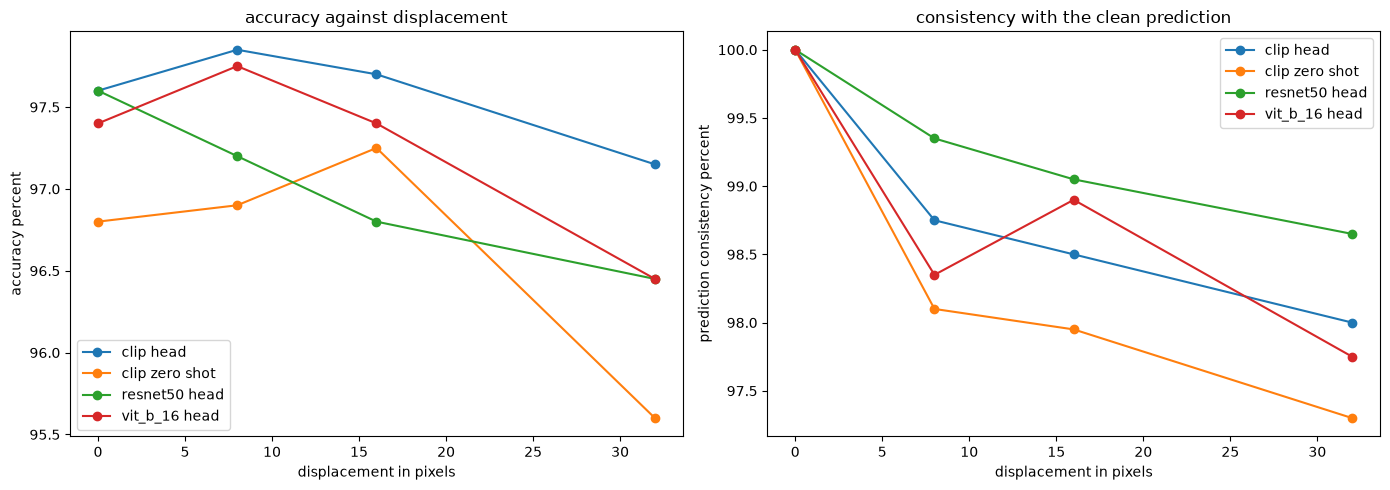

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name, group in translation_curve.groupby('model'):
    axes[0].plot(group['shift'], group['accuracy'], marker='o', label=model_name)
    axes[1].plot(group['shift'], group['prediction_consistency'], marker='o', label=model_name)

axes[0].set_xlabel('displacement in pixels')
axes[0].set_ylabel('accuracy percent')
axes[0].set_title('accuracy against displacement')
axes[0].legend()

axes[1].set_xlabel('displacement in pixels')
axes[1].set_ylabel('prediction consistency percent')
axes[1].set_title('consistency with the clean prediction')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'translation_curve.png', dpi=180, bbox_inches='tight')
plt.show()

## experiment 5 : patch structure


patch shuffled | resnet50:   0%|          | 0/4 [00:00<?, ?it/s]


patch shuffled | resnet50:  75%|███████▌  | 3/4 [00:00<00:00, 28.08it/s]


patch shuffled | vit_b_16:   0%|          | 0/4 [00:00<?, ?it/s]


patch shuffled | vit_b_16:  25%|██▌       | 1/4 [00:00<00:00,  9.55it/s]


patch shuffled | vit_b_16:  50%|█████     | 2/4 [00:00<00:00,  9.48it/s]


patch shuffled | vit_b_16:  75%|███████▌  | 3/4 [00:00<00:00,  9.45it/s]


patch shuffled | clip_vit_b_32:   0%|          | 0/4 [00:00<?, ?it/s]


patch shuffled | clip_vit_b_32: 100%|██████████| 4/4 [00:00<00:00, 35.83it/s]

,condition,model,accuracy,macro_f1,mean_max_confidence,prediction_consistency
0,patch shuffled,resnet50 head,89.800000,89.813112,0.868945,92.000002
1,patch shuffled,vit_b_16 head,88.999999,88.886107,0.900189,89.999998
2,patch shuffled,clip head,79.000002,78.943373,0.133588,79.000002
3,patch shuffled,clip zero shot,78.799999,78.861987,0.775117,80.199999


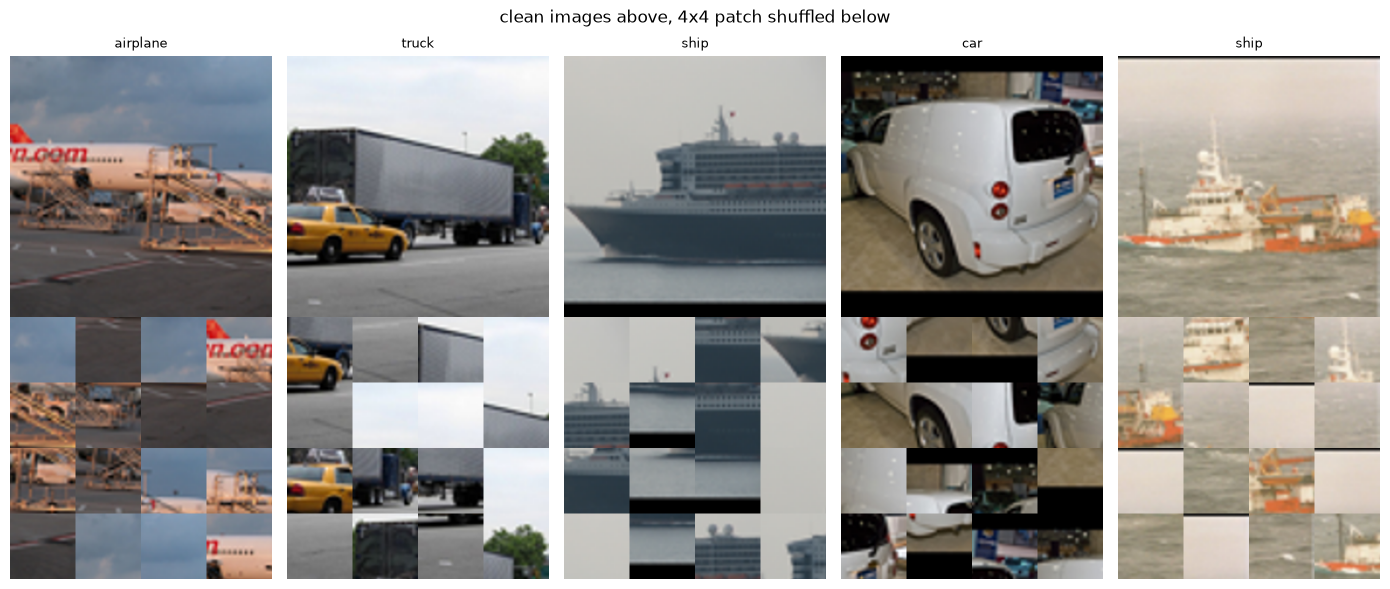

In [24]:
def patch_shuffled_images(images_uint8):
    patch_size = IMAGE_SIZE // PATCH_GRID
    number_of_patches = PATCH_GRID * PATCH_GRID
    identity = torch.arange(number_of_patches)
    generator = torch.Generator().manual_seed(SEED) #local generator so permutations dont drift

    patches = images_uint8.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size) #n,3,224,224 -> n,3,4,4,56,56
    patches = patches.permute(0, 2, 3, 1, 4, 5).reshape(len(images_uint8), number_of_patches, 3, patch_size, patch_size) #n,16,3,56,56

    shuffled = torch.empty_like(patches)
    for image_index in range(len(images_uint8)):
        permutation = torch.randperm(number_of_patches, generator=generator)
        while torch.equal(permutation, identity):
            permutation = torch.randperm(number_of_patches, generator=generator) #must be non identity, basically never happens with 16!
        shuffled[image_index] = patches[image_index][permutation]

    shuffled = shuffled.reshape(len(images_uint8), PATCH_GRID, PATCH_GRID, 3, patch_size, patch_size)
    return shuffled.permute(0, 3, 1, 4, 2, 5).reshape(len(images_uint8), 3, IMAGE_SIZE, IMAGE_SIZE)


#hypothesis -> local cue models lose less than ones needing global layout (4x4 != vit grid on purpose) | metric -> acc drop + consistency
patch_shuffled = patch_shuffled_images(eval_images)
patch_results, patch_predictions, patch_features = evaluate_condition('patch shuffled', patch_shuffled, eval_labels, clean_predictions)
patch_results.to_csv(OUTPUT_DIR / 'patch_shuffle.csv', index=False)
display(patch_results)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for column, position in enumerate(sample_positions):
    axes[0, column].imshow(eval_images[position].permute(1, 2, 0))
    axes[0, column].set_title(CLASS_NAMES[eval_labels[position]], fontsize=9)
    axes[0, column].axis('off')
    axes[1, column].imshow(patch_shuffled[position].permute(1, 2, 0))
    axes[1, column].axis('off')

plt.suptitle('clean images above, 4x4 patch shuffled below')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'patch_shuffle_examples.png', dpi=180, bbox_inches='tight')
plt.show()

## experiment 6 : representation analysis

In [25]:
def cosine_stability(clean_backbone_features, transformed_backbone_features):
    #this is I_T, mean cosine sim of row aligned clean vs transformed features (scale invariant)
    return F.cosine_similarity(clean_backbone_features, transformed_backbone_features, dim=1).mean().item()


stability_rows = []

for backbone_name in backbones:
    clean_backbone_features = clean_features[backbone_name]

    stability_rows.append({'backbone': backbone_name, 'transformation': 'grayscale',
                           'cosine_stability': cosine_stability(clean_backbone_features, colour_features['grayscale'][backbone_name])})

    stability_rows.append({'backbone': backbone_name, 'transformation': 'hue rotated',
                           'cosine_stability': cosine_stability(clean_backbone_features, colour_features['hue rotated'][backbone_name])})

    #realigned to each conflict's content image
    stability_rows.append({'backbone': backbone_name, 'transformation': 'cue conflict',
                           'cosine_stability': cosine_stability(clean_backbone_features[conflict_clean_positions],
                                                                conflict_features[backbone_name])})

    direction_stabilities = [cosine_stability(clean_backbone_features, direction_features[backbone_name])
                             for direction_features in representation_translation_features]
    stability_rows.append({'backbone': backbone_name, 'transformation': f'translation {REPRESENTATION_SHIFT}px',
                           'cosine_stability': float(np.mean(direction_stabilities))})

    stability_rows.append({'backbone': backbone_name, 'transformation': 'patch shuffled',
                           'cosine_stability': cosine_stability(clean_backbone_features, patch_features[backbone_name])})

representation_stability = pd.DataFrame(stability_rows)
representation_stability.to_csv(OUTPUT_DIR / 'representation_stability.csv', index=False)
display(representation_stability.pivot(index='backbone', columns='transformation', values='cosine_stability'))

transformation,cue conflict,grayscale,hue rotated,patch shuffled,translation 16px
backbone,,,,,
clip_vit_b_32,0.679562,0.893152,0.893592,0.738315,0.968018
resnet50,0.276215,0.788292,0.822733,0.717850,0.952493
vit_b_16,0.258346,0.739277,0.689440,0.652247,0.974320


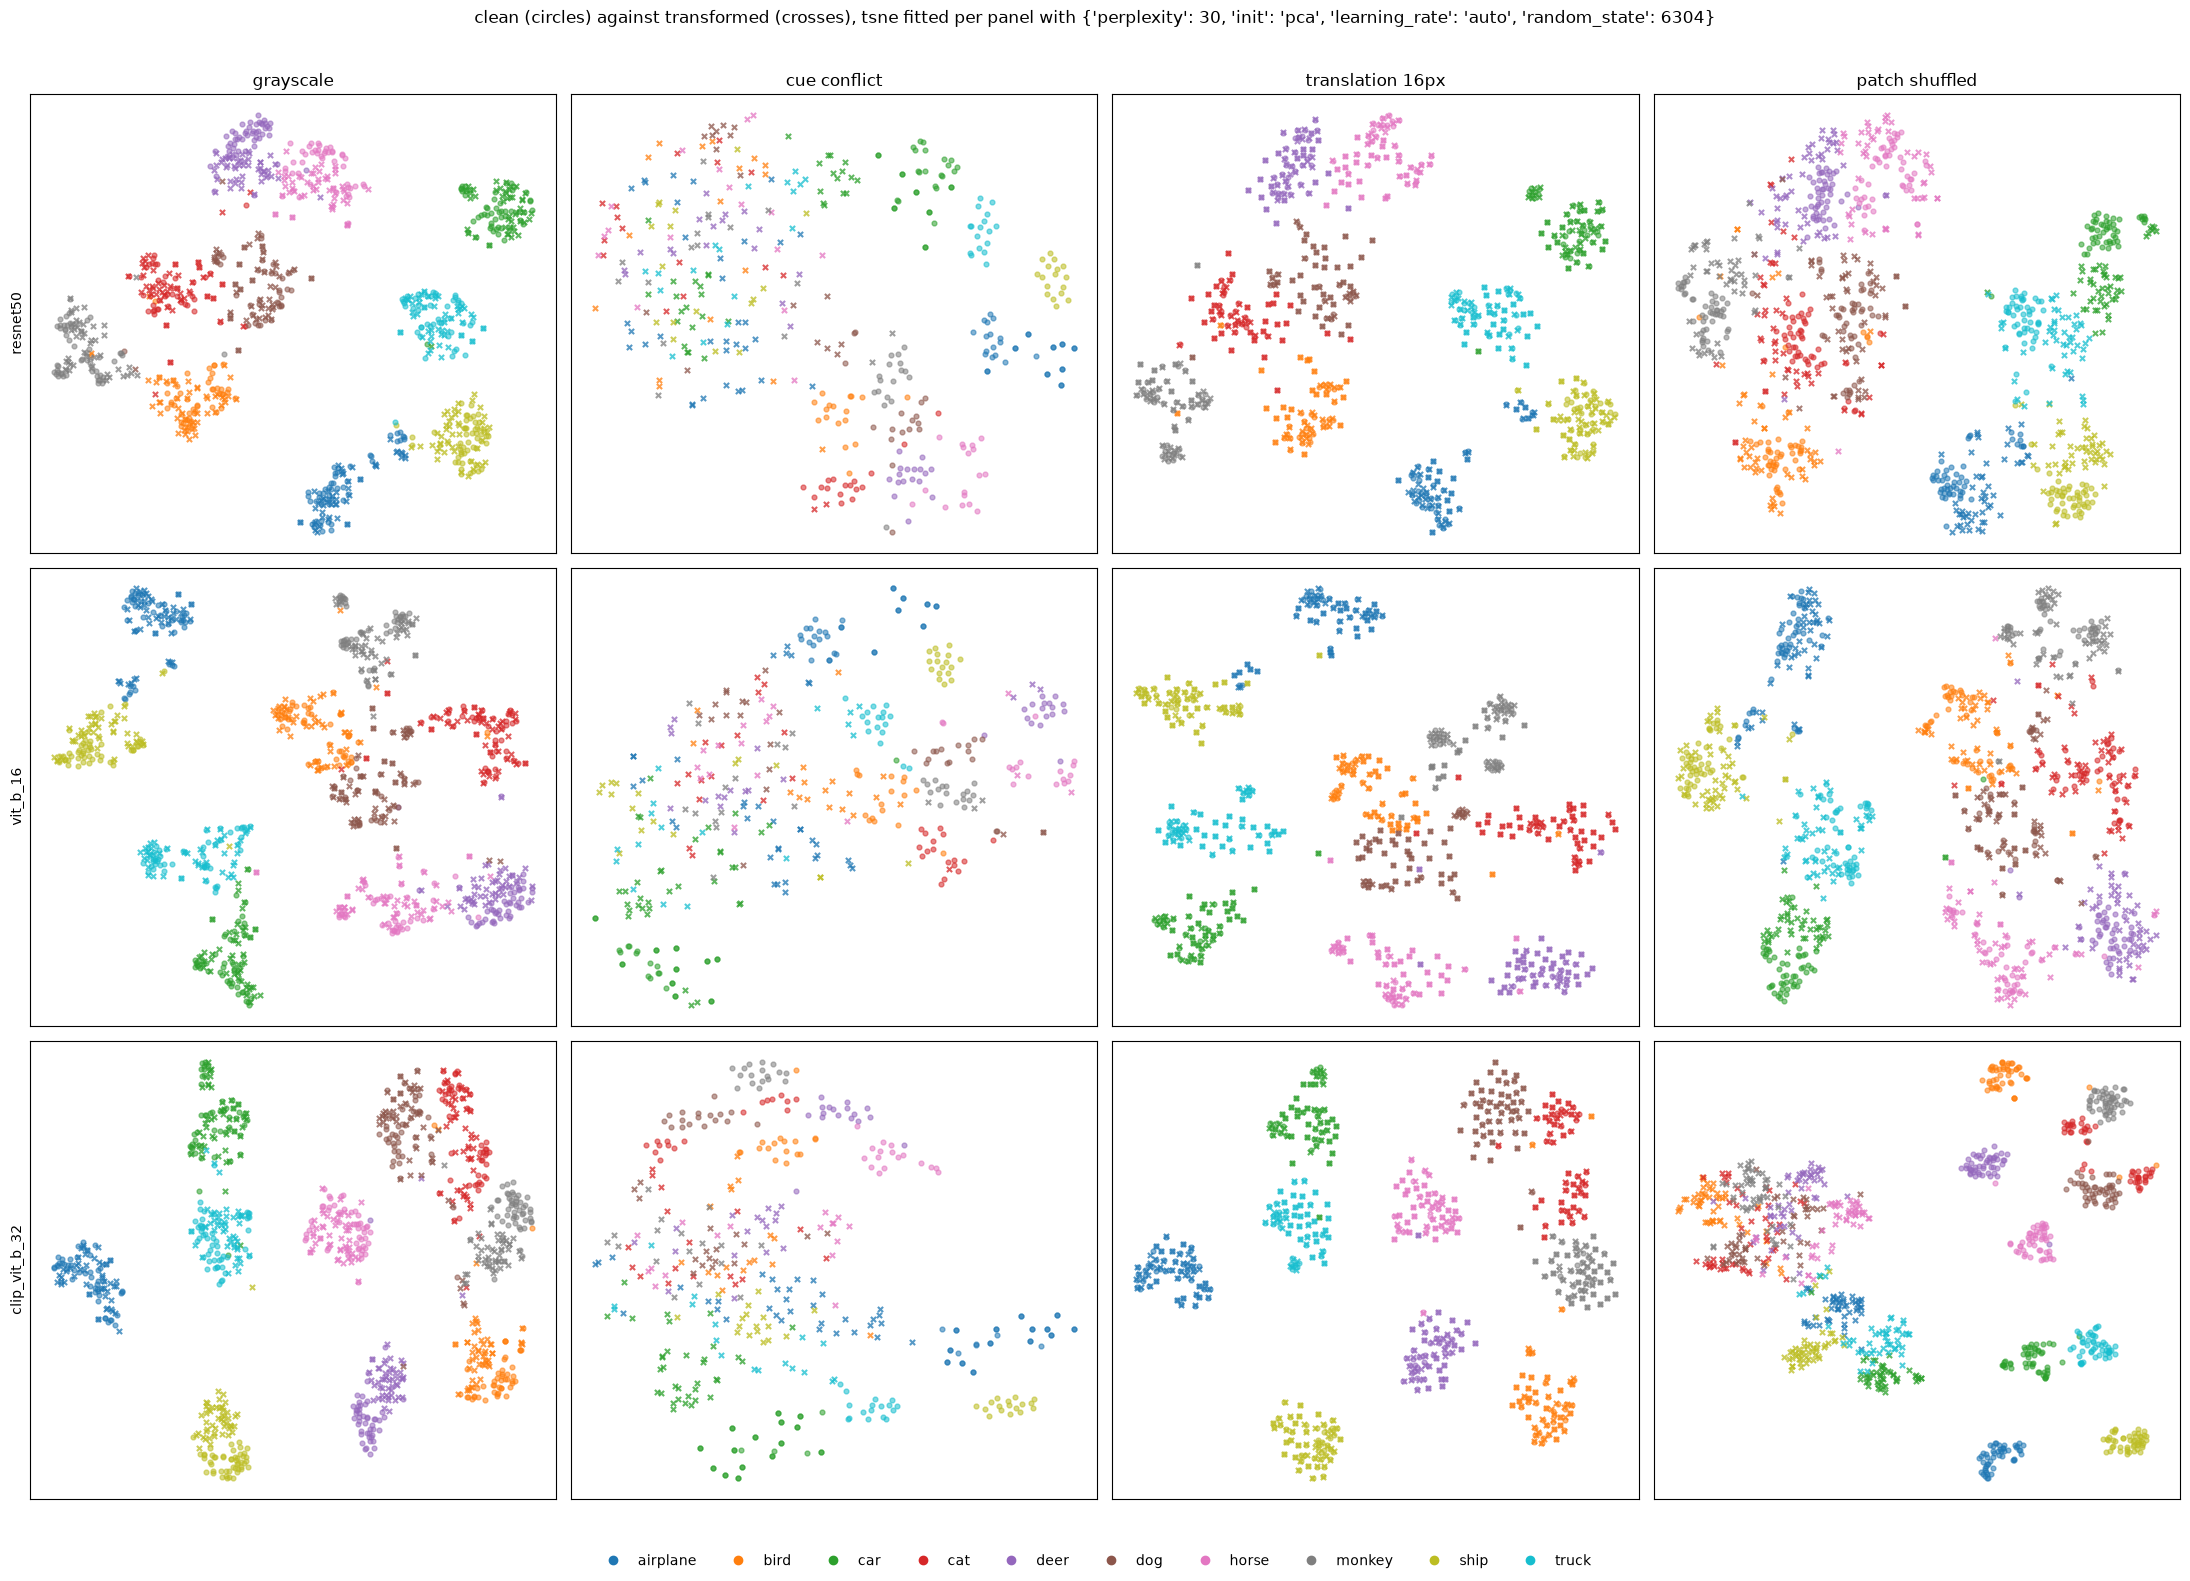

In [26]:
#one tsne per panel on clean+transformed together, coords arent comparable across panels
def project_pair(clean_backbone_features, transformed_backbone_features):
    combined = torch.cat([clean_backbone_features, transformed_backbone_features]).numpy()
    components = min(PCA_COMPONENTS, combined.shape[1]) #pca first cuz tsne is painfully slow
    reduced = PCA(n_components=components, random_state=SEED).fit_transform(combined)
    projected = TSNE(n_components=2, **TSNE_SETTINGS).fit_transform(reduced)
    return projected[:len(clean_backbone_features)], projected[len(clean_backbone_features):]


projection_conditions = { #(features, labels, clean positions)
    'grayscale': (colour_features['grayscale'], eval_labels, None),
    'cue conflict': (conflict_features, conflict_content_labels, conflict_clean_positions),
    f'translation {REPRESENTATION_SHIFT}px': (representation_translation_features[0], eval_labels, None),
    'patch shuffled': (patch_features, eval_labels, None),
}

colours = sns.color_palette('tab10', NUM_CLASSES)
fig, axes = plt.subplots(len(backbones), len(projection_conditions), figsize=(22, 16))

for row, backbone_name in enumerate(backbones):
    for column, (condition_name, (transformed_features, transformed_labels, clean_positions)) in enumerate(projection_conditions.items()):
        clean_backbone_features = clean_features[backbone_name] if clean_positions is None else clean_features[backbone_name][clean_positions]
        clean_labels = eval_labels if clean_positions is None else eval_labels[clean_positions]

        clean_projected, transformed_projected = project_pair(clean_backbone_features, transformed_features[backbone_name])
        axis = axes[row, column]

        for class_index in range(NUM_CLASSES):
            clean_mask = clean_labels.numpy() == class_index
            axis.scatter(clean_projected[clean_mask, 0], clean_projected[clean_mask, 1],
                         s=12, alpha=0.55, color=colours[class_index], marker='o')
            transformed_mask = transformed_labels.numpy() == class_index
            axis.scatter(transformed_projected[transformed_mask, 0], transformed_projected[transformed_mask, 1],
                         s=14, alpha=0.75, color=colours[class_index], marker='x')

        axis.set_xticks([])
        axis.set_yticks([])
        if row == 0:
            axis.set_title(condition_name)
        if column == 0:
            axis.set_ylabel(backbone_name)

legend_handles = [plt.Line2D([0], [0], marker='o', linestyle='none', color=colours[index], label=name)
                  for index, name in enumerate(CLASS_NAMES)]
fig.legend(handles=legend_handles, loc='lower center', ncol=10, frameon=False)
fig.suptitle(f"clean (circles) against transformed (crosses), tsne fitted per panel with {TSNE_SETTINGS}")
plt.tight_layout(rect=(0, 0.04, 1, 0.97))
plt.savefig(OUTPUT_DIR / 'representation_tsne.png', dpi=180, bbox_inches='tight')
plt.show()

## compact comparison across the interventions

In [27]:
summary = pd.concat([clean_results, colour_results, patch_results], ignore_index=True)
summary['accuracy_change'] = summary['accuracy'] - summary['model'].map(
    clean_results.set_index('model')['accuracy']
)

summary = summary[['condition', 'model', 'accuracy', 'accuracy_change', 'macro_f1',
                   'mean_max_confidence', 'prediction_consistency']]
summary.to_csv(OUTPUT_DIR / 'intervention_summary.csv', index=False)
display(summary.pivot(index='model', columns='condition', values='accuracy'))
display(summary)

condition,clean,grayscale,hue rotated,patch shuffled
model,,,,
clip head,97.600001,95.599997,94.999999,79.000002
clip zero shot,96.799999,94.199997,93.400002,78.799999
resnet50 head,97.600001,95.599997,93.199998,89.800000
vit_b_16 head,97.399998,95.599997,94.199997,88.999999


,condition,model,accuracy,accuracy_change,macro_f1,mean_max_confidence,prediction_consistency
0,clean,resnet50 head,97.600001,0.000000,97.605553,0.894992,NaN
1,clean,vit_b_16 head,97.399998,0.000000,97.389475,0.961627,NaN
2,clean,clip head,97.600001,0.000000,97.594204,0.161847,NaN
3,clean,clip zero shot,96.799999,0.000000,96.752408,0.942696,NaN
4,grayscale,resnet50 head,95.599997,-2.000004,95.586135,0.900452,96.399999
5,grayscale,vit_b_16 head,95.599997,-1.800001,95.585233,0.955041,95.200002
6,grayscale,clip head,95.599997,-2.000004,95.570626,0.155611,95.599997
7,grayscale,clip zero shot,94.199997,-2.600002,94.111822,0.928213,95.200002
8,hue rotated,resnet50 head,93.199998,-4.400003,93.246931,0.897188,94.599998
9,hue rotated,vit_b_16 head,94.199997,-3.200001,94.183716,0.923252,94.599998


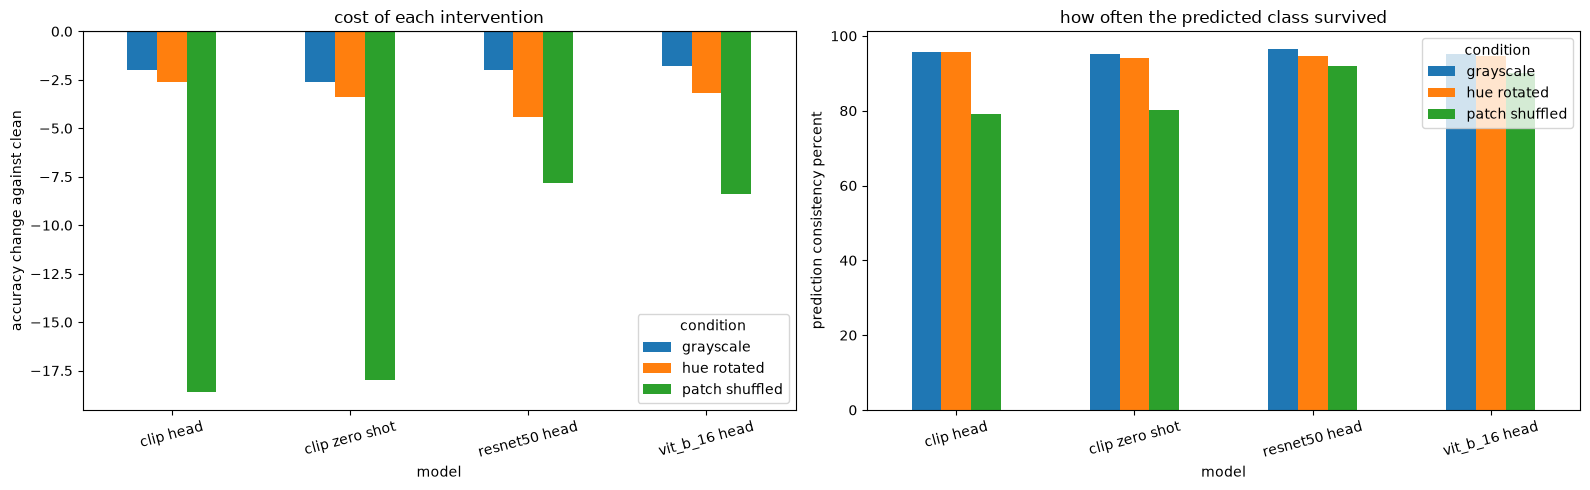

In [28]:
plot_frame = summary[summary['condition'] != 'clean'].pivot(index='model', columns='condition', values='accuracy_change')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_frame.plot(kind='bar', ax=axes[0], rot=15)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_ylabel('accuracy change against clean')
axes[0].set_title('cost of each intervention')
axes[0].legend(title='condition')

consistency_frame = summary[summary['condition'] != 'clean'].pivot(index='model', columns='condition', values='prediction_consistency')
consistency_frame.plot(kind='bar', ax=axes[1], rot=15)
axes[1].set_ylabel('prediction consistency percent')
axes[1].set_title('how often the predicted class survived')
axes[1].legend(title='condition')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'intervention_summary.png', dpi=180, bbox_inches='tight')
plt.show()

#frees the gpu for the next notebook
for entry in backbones.values():
    entry['model'] = entry['model'].cpu()
style_encoder = style_encoder.cpu()
style_decoder = style_decoder.cpu()
if torch.cuda.is_available():
    torch.cuda.empty_cache()